#Step 1 - Dataset extraction
The following cell downloads and extracts the dataset and then generate the configuration dictionary, which is displayed above. This dictionary (cfg) contains details such as the paths for training, validation and testing images, the number of classes, the class names and Roboflow project details.

In [6]:
#Import libraries
import os, hashlib, zipfile, urllib.request, yaml
from pathlib import Path

#Define dataset constants and paths
DATA_URL = "https://github.com/user-attachments/files/32692644/M4-U3.-.Assignment.v1i.yolov11.zip"
SHA256 = "087A862753D6427E53FA5615317F250693462B47974E048347102B423C7C5230"
ROOT = Path("/content/dataset")
ZIP_PATH = Path("/content/dataset.zip")

def sha256_file(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def find_data_yaml(root: Path):
    hits = list(root.rglob("data.yaml"))
    if not hits:
        raise FileNotFoundError(f"No data.yaml under {root}")
    return hits[0]

#Download dataset ZIP file and extract content into designated directory
already_ready = (ROOT / "data.yaml").exists() or any(ROOT.glob("*/data.yaml"))
if not already_ready:
    ROOT.mkdir(parents=True, exist_ok=True)
    if ZIP_PATH.exists():
        ZIP_PATH.unlink()
    urllib.request.urlretrieve(DATA_URL, ZIP_PATH)
    digest = sha256_file(ZIP_PATH)
    if digest != SHA256.lower():
        ZIP_PATH.unlink(missing_ok=True)
        raise AssertionError(f"Checksum mismatch: {digest}")
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(ROOT)

#Update dataset with training, validation and testing paths and print updated dataset configuration
cfg_path = find_data_yaml(ROOT)
dataset_root = cfg_path.parent
cfg = yaml.safe_load(cfg_path.read_text())
cfg["path"] = str(dataset_root)
cfg["train"] = "train/images"
cfg["val"] = "valid/images"
if (dataset_root / "test" / "images").is_dir():
    cfg["test"] = "test/images"
else:
    cfg.pop("test", None)
cfg_path.write_text(yaml.safe_dump(cfg, sort_keys=False))
print(cfg)

{'train': 'train/images', 'val': 'valid/images', 'test': 'test/images', 'nc': 1, 'names': ['Concrete spalling'], 'roboflow': {'workspace': 'valentina-votter', 'project': 'm4-u3-assignment-d3j9b', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/valentina-votter/m4-u3-assignment-d3j9b/dataset/1'}, 'path': '/content/dataset'}


#Step 2 - Training

In [4]:
data=str(cfg_path)

In [ ]:
!pip install ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 5.3 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO

# Load a pretrained YOLO model
model = YOLO("yolov8n.pt")

# Train the model on the COCO8 dataset for 10 epochs
train_results = model.train(
    data="coco8.yaml",
    epochs=10,
    imgsz=640,
    device="cpu",
)

# Evaluate the model's performance on the validation set
metrics = model.val()

# Perform object detection
# Fixed: Using the URL directly since the local file wasn't found
image_url = "https://images.pexels.com/photos/1216589/pexels-photo-1216589.jpeg"
results = model(image_url)

# Export the model to ONNX format
path = model.export(format="onnx")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics 8.4.142 🚀 Python-3.13.15 torch-2.11.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco8.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from ultralytics import YOLO

# 1. Define the source image and initialize the model
image_url = 'https://images.pexels.com/photos/1216589/pexels-photo-1216589.jpeg'
model = YOLO("yolov8n.pt")

# 2. Run the inspection
# conf=0.5 means "Only speak up if you are 50% sure"
results = model.predict(source=image_url, save=True, conf=0.5)


Found https://images.pexels.com/photos/1216589/pexels-photo-1216589.jpeg locally at pexels-photo-1216589.jpeg
image 1/1 /content/pexels-photo-1216589.jpeg: 448x640 2 persons, 209.9ms
Speed: 9.1ms preprocess, 209.9ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict


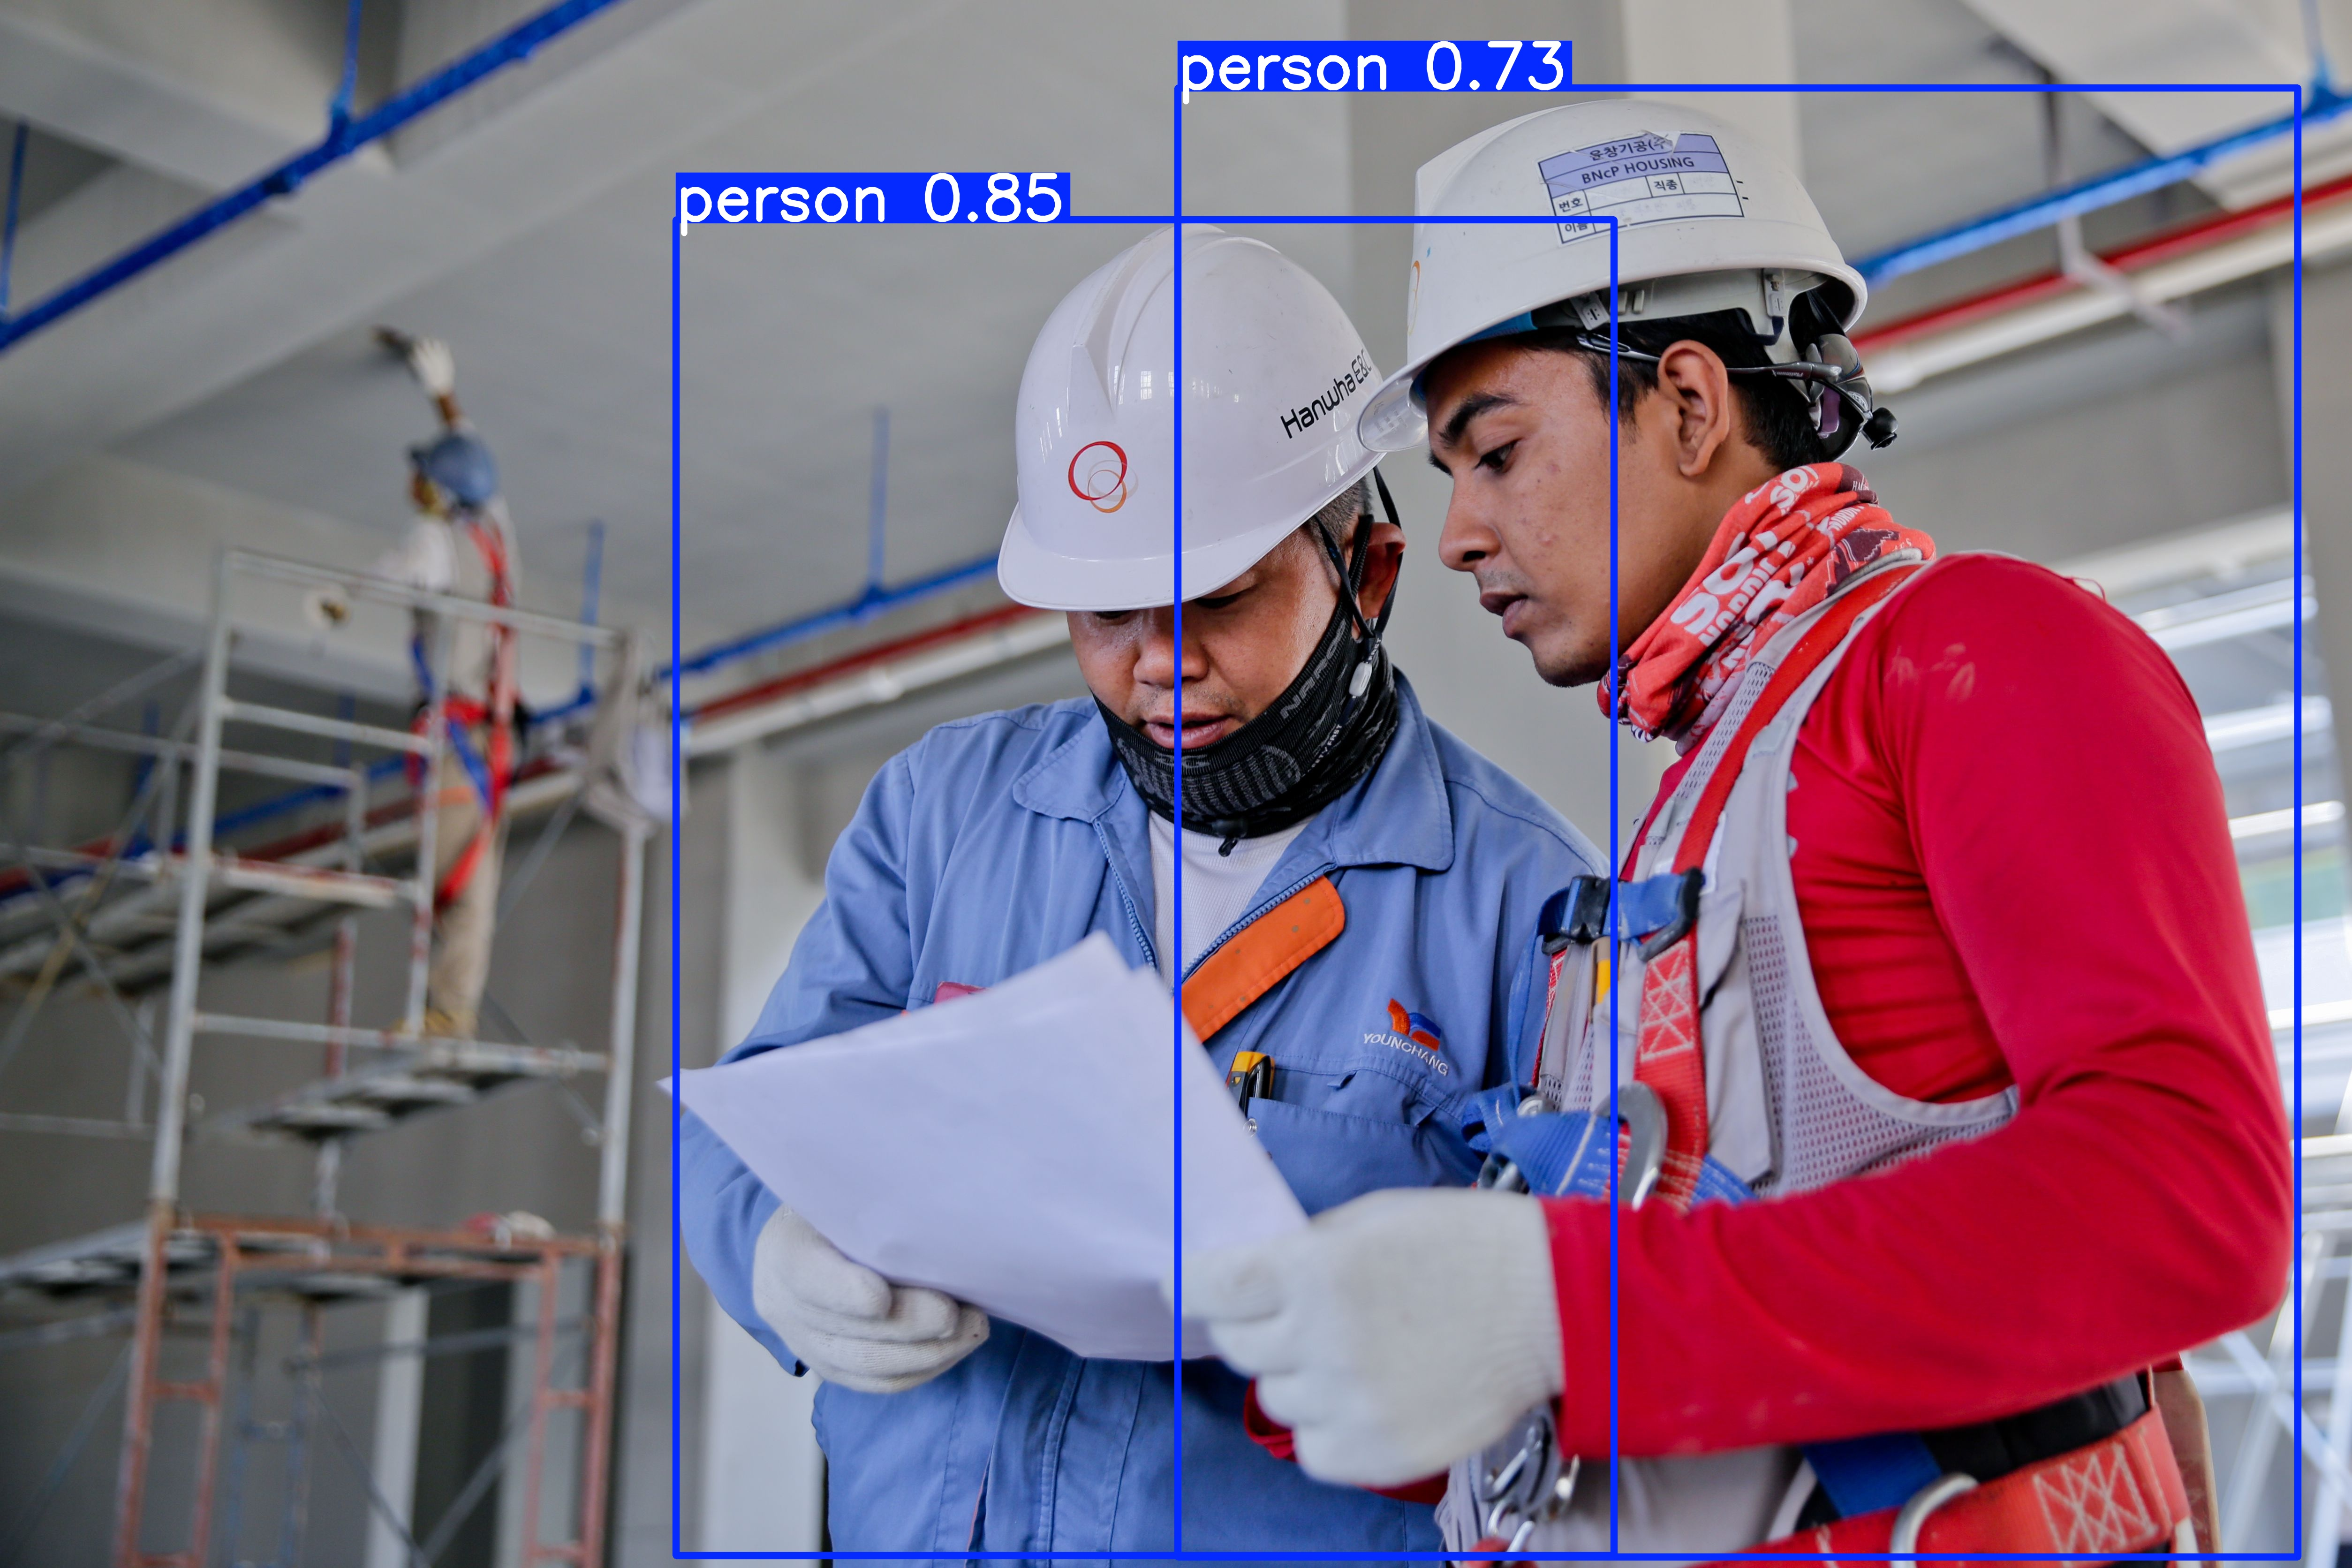

In [ ]:
# Display the image right here in the notebook
from IPython.display import Image
Image(filename='/content/runs/detect/predict/pexels-photo-1216589.jpg')

In [ ]:
print(model.names)          # dict: class_id -> class_name
print(len(model.names))     # should be 80 for COCO


{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw